In [ ]:
import os
import paths

os.chdir(paths.PROJECT_ROOT)

# MESM calibration

Calibrates the SCM to MESM in three stages:

| component | fitted to |
|---|---|
| carbon cycle (emissions -> concentration) | `1pctCO2` |
| ECS, i.e. $\sum_j q_j$ | `abrupt-2xCO2` equilibrium |
| thermal timescales $d_j$, partition of $q$ | `1pctCO2` transient + Tier 1 |

The adopted parameters are written to `data/JAX_calibration/calib_MESM_tier1_augmented.pkl` and transcribed into `utils_FaIR_JAX.MESM_TIER1_PARAMS`.


In [1]:
import glob
import pickle
import importlib.util
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import jax.numpy as jnp

import utils_FaIR_JAX
import utils_inverse
import utils_plotting
from paths import DATA_DIR

## Setup plots
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({
  "text.usetex": True,
  "font.family": "sans-serif",
  "font.sans-serif": ["Helvetica Light"],
})

%load_ext autoreload
%autoreload 2

### Phase 1: carbon cycle, emissions -> concentration (1pctCO2)


In [ ]:
emis_path = str(DATA_DIR / 'MESM' / 'emis_driven')

emis_1pct_path = f'{emis_path}/1PRCO2/carbemiss.txt'
emis_1pct = np.loadtxt(emis_1pct_path, usecols=(2,), skiprows=2)
emis_mat_1pct = jnp.zeros((5, len(emis_1pct)))
emis_mat_1pct = emis_mat_1pct.at[0,:].set(emis_1pct)

emis_2xco2_path = f'{emis_path}/2xCO2/implco2emiss.3100.25.txt'
emis_2xco2 = np.loadtxt(emis_2xco2_path, usecols=(2,))
emis_mat_2xco2 = jnp.zeros((5, len(emis_2xco2)))
emis_mat_2xco2 = emis_mat_2xco2.at[0,:].set(emis_2xco2)

# Phase 1's calibration input: 1pctCO2 only.
emis_dict_1pct = {'1pctCO2': emis_mat_1pct}

# Phase 3's verification input: both experiments' real emissions.
emis_dict = {'1pctCO2': emis_mat_1pct, '2xCO2': emis_mat_2xco2}

In [ ]:
# Target CO2 concentration curve for the carbon-cycle fit
base_co2 = 286.4

# 1pct/yr increase
co2_1pct = base_co2 * (1.01 ** np.arange(len(emis_1pct)))
conc_mat_1pct_carbon = jnp.zeros((3, len(co2_1pct)))
conc_mat_1pct_carbon = conc_mat_1pct_carbon.at[0,:].set(co2_1pct)
conc_mat_1pct_carbon = conc_mat_1pct_carbon.at[1,:].set(720.0)
conc_mat_1pct_carbon = conc_mat_1pct_carbon.at[2,:].set(270.0)

target_conc_dict_1pct = {'1pctCO2': conc_mat_1pct_carbon}

In [ ]:
# Run calibration on 1pctCO2
CARBON_FILEPATH = 'data/JAX_calibration/calib_MESM_emis_to_conc_both.pkl'
theta0 = utils_FaIR_JAX.make_theta0(mode='FaIR')
theta_opt_emis, _ = utils_FaIR_JAX.calibrate_carbon_cycle(
    CARBON_FILEPATH, emis_dict_1pct, target_conc_dict_1pct, theta0, dt=0.1, n_steps=200,
    learning_rate=1e-2, mode='FaIR', base_params=utils_FaIR_JAX.MESM_PARAMS,
)

Starting Carbon Cycle Calibration (Emis -> Conc)...


Step 0 | Loss (Conc MSE): 287.6098


Step 100 | Loss (Conc MSE): 25.8132


Step 199 | Loss (Conc MSE): 16.3085


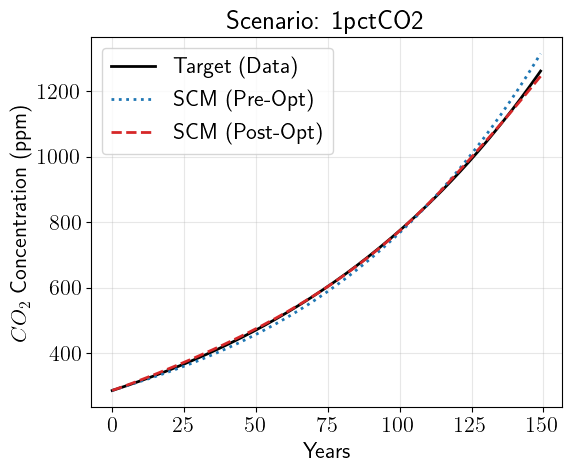

In [5]:
utils_plotting.plot_calibration_results(
    None, emis_dict_1pct, target_conc_dict_1pct, theta0, theta_opt_emis, dt=0.1,
    calib='Carbon', base_params=utils_FaIR_JAX.MESM_PARAMS,
)

### Phase 2a: energy balance from the DECK experiments

ECS pinned from abrupt-2xCO2, timescales from the 1pctCO2 transient.

In [ ]:
conc_path = str(DATA_DIR / 'MESM' / 'conc_driven')

def calculate_ensemble_average(file_pattern):
    # Find all files matching the string pattern (e.g., 'dt2m_ascii_*.txt')
    file_list = glob.glob(file_pattern)

    if not file_list:
        print("No files found matching the pattern.")
        return None

    all_data = []
    for file in file_list:
        # usecols=(1,) extracts the GMST anomaly column
        data = np.loadtxt(file, usecols=(1,))
        all_data.append(data)

    ensemble_stack = np.stack(all_data)
    return np.mean(ensemble_stack, axis=0)

avg_1pct = calculate_ensemble_average(f'{conc_path}/1PRCO2/dt2m_ascii_*.txt')
avg_2xco2 = calculate_ensemble_average(f'{conc_path}/2CO2/dt2m_ascii_*.txt')

In [ ]:
# ECS measured from abrupt-2xCO2
mesm_ecs = float(np.mean(avg_2xco2[-50:]))

# ECS = F_2xCO2 * sum(q), and F_2xCO2 is fixed by the RF formula 
# Inverting gives the sum(q) the thermal fit must respect
F2x = float(utils_FaIR_JAX.radiative_forcing_co2(2 * base_co2, utils_FaIR_JAX.MESM_PARAMS))
sum_q_target = mesm_ecs / F2x

print(f"MESM abrupt-2xCO2 equilibrium (ECS) = {mesm_ecs:.3f} K")
print(f"F_2xCO2 (fixed by RF formula)       = {F2x:.4f} W/m2")
print(f"=> pinned sum(q)                    = {sum_q_target:.4f} K/(W/m2)")
print(f"MESM 1pctCO2 TCR (yr 70, 2x crossing) = {avg_1pct[70]:.3f} K"
      f"  -> TCR/ECS = {avg_1pct[70]/mesm_ecs:.3f}")

MESM abrupt-2xCO2 equilibrium (ECS) = 3.205 K
F_2xCO2 (fixed by RF formula)       = 3.7748 W/m2
=> pinned sum(q)                    = 0.8490 K/(W/m2)
MESM 1pctCO2 TCR (yr 70, 2x crossing) = 1.775 K  -> TCR/ECS = 0.554


In [ ]:
# Prescribed CO2 concentration paths
n_years_1pct = len(avg_1pct)
n_years_2xco2 = len(avg_2xco2)

co2_1pct = base_co2 * (1.01 ** np.arange(n_years_1pct))
conc_mat_1pct = jnp.zeros((3, n_years_1pct))
conc_mat_1pct = conc_mat_1pct.at[0,:].set(co2_1pct)
conc_mat_1pct = conc_mat_1pct.at[1,:].set(720.0)
conc_mat_1pct = conc_mat_1pct.at[2,:].set(270.0)

co2_2xco2 = jnp.full(n_years_2xco2, 2 * base_co2)
conc_mat_2xco2 = jnp.zeros((3, n_years_2xco2))
conc_mat_2xco2 = conc_mat_2xco2.at[0,:].set(co2_2xco2)
conc_mat_2xco2 = conc_mat_2xco2.at[1,:].set(720.0)
conc_mat_2xco2 = conc_mat_2xco2.at[2,:].set(270.0)

# Phase 2's fit: 1pctCO2 only.
conc_dict_fit   = {'1pctCO2': conc_mat_1pct}
target_dict_fit = {'1pctCO2': avg_1pct}
emis_dict_climate_fit = {'1pctCO2': jnp.zeros((5, n_years_1pct))}

# Both experiments, for the diagnostic plot
conc_dict_both   = {'1pctCO2': conc_mat_1pct, '2xCO2': conc_mat_2xco2}
target_dict_both = {'1pctCO2': avg_1pct, '2xCO2': avg_2xco2}
emis_dict_climate_both = {'1pctCO2': jnp.zeros((5, n_years_1pct)),
                          '2xCO2': jnp.zeros((5, n_years_2xco2))}

In [ ]:
# Calibrate climate sensitivity
CLIMATE_FILEPATH = 'data/JAX_calibration/calib_MESM_CO2_only_both.pkl'
theta_opt, _ = utils_FaIR_JAX.calibrate_climate_sensitivity(
    CLIMATE_FILEPATH, emis_dict_climate_fit, conc_dict_fit, target_dict_fit, theta_opt_emis,
    dt=0.1, n_steps=1000, learning_rate=1e-2, base_params=utils_FaIR_JAX.MESM_PARAMS,
    sum_q_target=sum_q_target,
)

_pf = utils_FaIR_JAX.params_from_theta(theta_opt, utils_FaIR_JAX.MESM_PARAMS)
_o = np.argsort(np.asarray(_pf['d']))
print(f"\n  fitted d (yr) = {np.round(np.asarray(_pf['d'])[_o], 2)}")
print(f"  fitted q      = {np.round(np.asarray(_pf['q'])[_o], 4)}  (sum={float(jnp.sum(_pf['q'])):.4f})")
print(f"  => ECS = {F2x*float(jnp.sum(_pf['q'])):.2f} K (pinned to MESM's {mesm_ecs:.2f} K)")

Starting Climate Sensitivity Calibration (Conc -> Temp)...


Step 0 | Loss (Temp MSE): 0.0868
Step 100 | Loss (Temp MSE): 0.0018
Step 200 | Loss (Temp MSE): 0.0015
Step 300 | Loss (Temp MSE): 0.0014


Step 400 | Loss (Temp MSE): 0.0013
Step 500 | Loss (Temp MSE): 0.0012
Step 600 | Loss (Temp MSE): 0.0011
Step 700 | Loss (Temp MSE): 0.0010


Step 800 | Loss (Temp MSE): 0.0010
Step 900 | Loss (Temp MSE): 0.0009
Step 999 | Loss (Temp MSE): 0.0008

  fitted d (yr) = [  0.7   17.43 179.65]
  fitted q      = [0.2123 0.269  0.3677]  (sum=0.8490)
  => ECS = 3.20 K (pinned to MESM's 3.20 K)


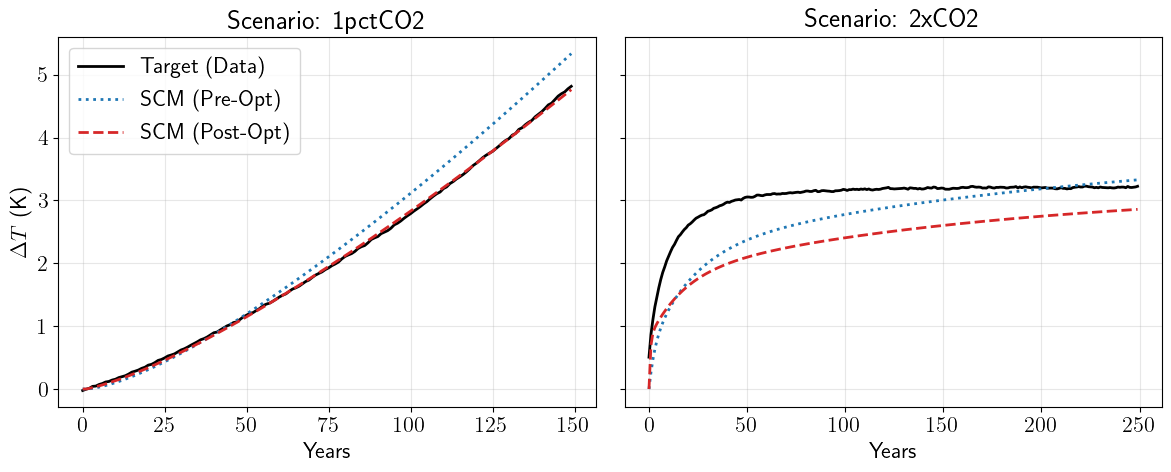

In [10]:
utils_plotting.plot_calibration_results(
    conc_dict_both, emis_dict_climate_both, target_dict_both, theta_opt_emis, theta_opt, dt=0.1,
    base_params=utils_FaIR_JAX.MESM_PARAMS,
)

### Phase 2b: add the Tier 1 scenarios to the timescale fit


In [ ]:
import jax
import optax

PROJECT_ROOT = Path.cwd()
_spec_tier1 = importlib.util.spec_from_file_location(
    "s02d_tier1", PROJECT_ROOT / "pipeline" / "02_scm_calibration" / "02d_tier1_dataset.py")
tier1_mod = importlib.util.module_from_spec(_spec_tier1)
_spec_tier1.loader.exec_module(tier1_mod)

AGENTS_T1 = ("CO2",)
tier1_emis, tier1_truth = tier1_mod.build_tier1_dataset()

# Training set: all seven Tier 1 scenarios + 1pctCO2.
TRAIN_T1 = tier1_mod.TIER1_SCORED_SCENARIOS + ["1pctCO2"]

yrs_h_t1, emis_h_t1 = utils_inverse.extract_years_and_emis(
    tier1_emis["historical"], agents=AGENTS_T1)
per_scen_t1 = {}
for s in tier1_mod.TIER1_FUTURE_SCENARIOS:      # every one of these is in scens_with_hist
    y, e = utils_inverse.extract_years_and_emis(tier1_emis[s], agents=AGENTS_T1)
    per_scen_t1[s] = dict(years_curr=y, emis_curr_dict=e,
                          years_hist=yrs_h_t1, emis_hist_dict=emis_h_t1)
per_scen_t1["historical"] = dict(years_curr=yrs_h_t1, emis_curr_dict=emis_h_t1,
                                 years_hist=None, emis_hist_dict=None)
y, e = utils_inverse.extract_years_and_emis(tier1_emis["1pctCO2"], agents=AGENTS_T1)
per_scen_t1["1pctCO2"] = dict(years_curr=y, emis_curr_dict=e,
                              years_hist=None, emis_hist_dict=None)
hist_len_t1 = int(tier1_truth["historical"].shape[0])
print("training scenarios:", TRAIN_T1)

training scenarios: ['H-ext', 'M', 'ML', 'L', 'VLHO', 'VLLO-ext', 'historical', '1pctCO2']


In [ ]:
def _project_sumq(th, target):
    """Same ECS constraint as Phase 2a, applied inside this fit's own loss."""
    q = jnp.exp(th[8:11])
    q = q * (target / jnp.sum(q))
    return th.at[8:11].set(jnp.log(q))

def _scen_nrmse_t1(th, scen):
    """Per-scenario NRMSE through the FULL emissions -> temperature pipeline."""
    params = utils_FaIR_JAX.params_from_theta(
        _project_sumq(th, sum_q_target), base_params=utils_FaIR_JAX.MESM_PARAMS)
    pred = utils_inverse.simulate_targets_gmst(
        mode="MESM", dt=0.1, params=params, use_checkpoint=True,
        **per_scen_t1[scen])
    if scen == "historical":
        pred = pred[tier1_mod.EMIS_OFFSET_HIST:tier1_mod.EMIS_OFFSET_HIST + hist_len_t1]
    true = tier1_truth[scen]
    n = min(pred.shape[0], true.shape[0])
    return utils_FaIR_JAX.calc_nrmse(pred[:n], true[:n]), n

vg_t1 = {s: jax.value_and_grad(lambda th, ss=s: _scen_nrmse_t1(th, ss)[0]) for s in TRAIN_T1}
lens_t1 = jnp.asarray([_scen_nrmse_t1(theta_opt_emis, s)[1] for s in TRAIN_T1], dtype=jnp.float32)
w_t1 = lens_t1 / jnp.sum(lens_t1)   # length-weighted (spans 127-477 yr)

N_STEPS_T1 = 300
opt = optax.adam(learning_rate=1e-2)
theta_t1 = theta_opt_emis                       # chained from Phase 1's carbon cycle
opt_state = opt.init(theta_t1)
mask_clim = utils_FaIR_JAX.make_theta_mask(theta_t1, target="Climate")

print(f"Tier1-augmented timescale fit: {len(TRAIN_T1)} scenarios, {N_STEPS_T1} steps "
      f"(~2.4 s/step) ...")
for step in range(N_STEPS_T1):
    ls, gs = [], []
    for s in TRAIN_T1:
        l, g = vg_t1[s](theta_t1)
        ls.append(l); gs.append(g)
    loss = jnp.sum(jnp.stack(ls) * w_t1)
    grad = jnp.sum(jnp.stack(gs) * w_t1[:, None], axis=0) * mask_clim
    updates, opt_state = opt.update(grad, opt_state, theta_t1)
    theta_t1 = optax.apply_updates(theta_t1, updates)
    if (step + 1) % 10 == 0:
        jax.clear_caches()
    if step % 25 == 0 or step == N_STEPS_T1 - 1:
        print(f"  step {step:3d} | length-weighted mean NRMSE: {float(loss):.4f}", flush=True)

theta_opt_t1 = _project_sumq(theta_t1, sum_q_target)

_pt = utils_FaIR_JAX.params_from_theta(theta_opt_t1, utils_FaIR_JAX.MESM_PARAMS)
_ot = np.argsort(np.asarray(_pt['d']))
print(f"\n  Phase 2b d (yr) = {np.round(np.asarray(_pt['d'])[_ot], 2)}")
print(f"  Phase 2b q      = {np.round(np.asarray(_pt['q'])[_ot], 4)}  (sum={float(jnp.sum(_pt['q'])):.4f})")
print(f"  => ECS = {F2x*float(jnp.sum(_pt['q'])):.2f} K (still pinned to MESM's {mesm_ecs:.2f} K)")

TIER1_FILEPATH = 'data/JAX_calibration/calib_MESM_tier1_augmented.pkl'
with open(TIER1_FILEPATH, 'wb') as f:
    pickle.dump(theta_opt_t1, f)
print(f"\n  adopted calibration saved -> {TIER1_FILEPATH}")

Tier1-augmented timescale fit: 8 scenarios, 300 steps (~2.4 s/step) ...


  step   0 | length-weighted mean NRMSE: 0.1463


  step  25 | length-weighted mean NRMSE: 0.1152


  step  50 | length-weighted mean NRMSE: 0.1072


  step  75 | length-weighted mean NRMSE: 0.1032


...

  step 225 | length-weighted mean NRMSE: 0.0954


  step 250 | length-weighted mean NRMSE: 0.0948


  step 275 | length-weighted mean NRMSE: 0.0945


  step 299 | length-weighted mean NRMSE: 0.0943



  Phase 2b d (yr) = [ 0.53 70.1  89.46]
  Phase 2b q      = [0.2417 0.292  0.3153]  (sum=0.8490)
  => ECS = 3.20 K (still pinned to MESM's 3.20 K)

  adopted calibration saved -> data/JAX_calibration/calib_MESM_tier1_augmented.pkl


### Phase 3: emissions to temperature (verification)


Phase 2a (DECK-only timescales):


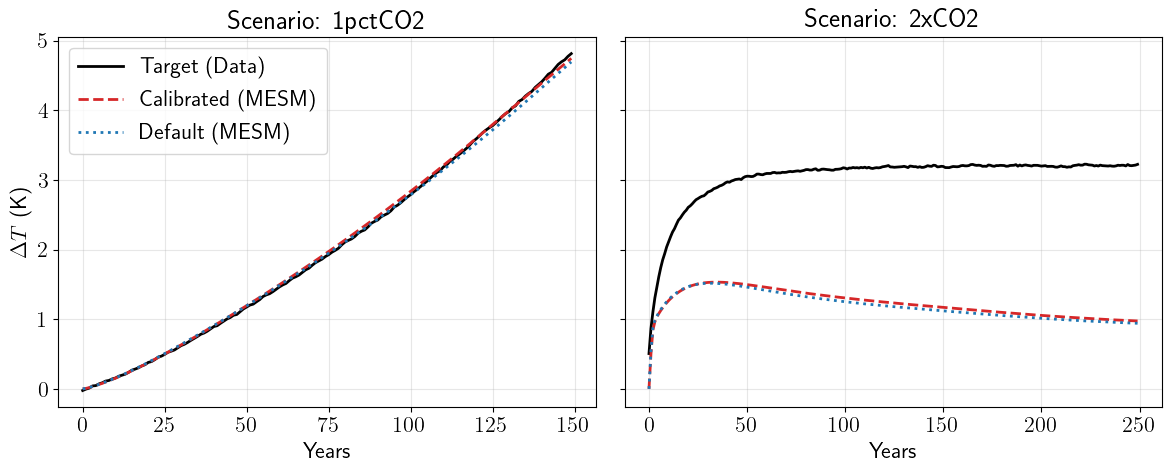

Phase 2b (Tier1-augmented timescales):


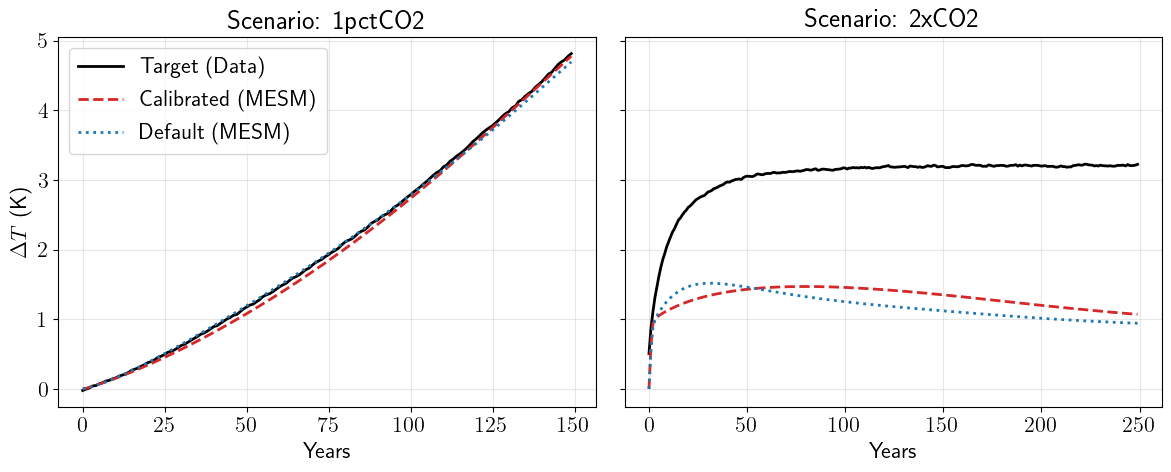

In [13]:
# Full emissions -> temperature pipeline on both DECK experiments, for the
# Phase 2a (DECK-only) and Phase 2b (Tier1-augmented) thermal fits.
target_dict_verify = {'1pctCO2': avg_1pct, '2xCO2': avg_2xco2}
print("Phase 2a (DECK-only timescales):")
utils_plotting.plot_model_comparison(emis_dict, target_dict_verify, theta_opt, mode='MESM', dt=0.1)
print("Phase 2b (Tier1-augmented timescales):")
utils_plotting.plot_model_comparison(emis_dict, target_dict_verify, theta_opt_t1, mode='MESM', dt=0.1)